# Chapter 12 — Actuators and Control: Hands-On Python Practice
## *Fundamentals of the Internet of Things*
**Oleksandr Kuznetsov** · eCampus University, Novedrate (CO), Italy

---

> **How to use this notebook.** Each exercise is self-contained: read the
> background, run the code cells in order, study the plots, then try the
> challenge tasks listed for that exercise **in the printed chapter**
> (Section 12.3 of the book) — they are not duplicated here, to keep this
> notebook focused on the core simulations.

| Exercise | Topic | Key technique |
|----------|-------|----------------|
| 12.1 | Electromagnetic solenoid actuator | Coupled RL-circuit / mass–spring–damper ODE |
| 12.2 | PWM-driven DC motor | Averaged-voltage model (`odeint`) + switched model (fixed-step Euler) with ideal-diode conduction-mode clamp |
| 12.3 | Open-loop vs. closed-loop control | Discrete-time PID controller with honest settling/recovery metrics |
| 12.4 | Piezoelectric vs. SMA actuators | Hysteresis operator + lumped thermal model |

---
## Setup

Shared imports, plotting style, and library versions (for reproducibility) used throughout the notebook.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import odeint

np.random.seed(42)  # most experiments below are deterministic ODEs/discrete
                     # simulations, not stochastic models; the seed is set
                     # for consistency with this book's other notebooks and
                     # in case a challenge task adds sensor noise

print(f"numpy      {np.__version__}")
print(f"scipy      {scipy.__version__}")
print(f"matplotlib {matplotlib.__version__}")

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 1.6,
})

numpy      2.4.4
scipy      1.17.1
matplotlib 3.10.8


---
## Exercise 12.1 — Electromagnetic Solenoid Actuator: Coupled Electrical–Mechanical Dynamics

### Background

A pull-type solenoid is the simplest and most widely used electromagnetic
actuator in IoT products: door locks, valves, and relay-style switches all
rely on the same basic physics. Applying a voltage across the coil builds
up a current; the resulting magnetic field pulls a ferromagnetic core
against a return spring.

### Model

$$
L\,\frac{di}{dt} = V - Ri, \qquad
m\,\frac{dv}{dt} = F_{em}(i) - k_{spring}\,x - b\,v, \qquad
F_{em}(i) = \tfrac{1}{2}K_f\,i^2
$$

The reluctance force $F_{em}$ stands in for the true, position-dependent
relationship $F_{em} = \tfrac{1}{2}i^2\,dL/dx$, treating $K_f$ as a
constant. **This is an important modelling caveat:** the fully coupled
equation would read
$V = Ri + L(x)\,di/dt + i\,(dL/dx)(dx/dt)$, with a back-EMF term that
feeds the core's motion back into the electrical equation. Dropping that
term (as this simplified model does) makes the model **not
energy-conserving** — mechanical work appears without a matching drop in
electrical/magnetic energy. The model below is valid for studying
transient *shape* (overshoot, settling time, the electrical/mechanical
timescale interplay) but **must not** be used to estimate energy
efficiency; see Challenge 1 in the printed chapter for the fully coupled
alternative.

### Learning objectives

1. Simulate the coupled electrical and mechanical dynamics of a solenoid actuator.
2. Identify the electrical time constant and the mechanical natural frequency, and see how their ratio shapes the response.
3. Quantify overshoot, settling time, and rise time for a realistic small solenoid, using a simulation window long enough to actually reach steady state.
4. Understand why voltage and displacement do *not* scale the same way (displacement scales with $V^2$, not $V$).

In [2]:
# ── Exercise 12.1: Electromagnetic solenoid actuator ──────────────────
class SolenoidActuator:
    """Coupled electrical-mechanical model of a pull-type solenoid.

    State: [x (core displacement, m), v (core velocity, m/s), i (coil current, A)]

    IMPORTANT MODELLING CAVEAT: this model treats the electromagnetic
    force constant Kf as independent of core position, which decouples
    the electrical equation from the mechanical one. A real solenoid's
    inductance L(x) depends on core position, and the fully coupled model
    would include a back-EMF term i*(dL/dx)*(dx/dt) in the electrical
    equation. Because that term is omitted here, this reduced model does
    NOT conserve energy and must only be used to study the transient
    *shape* of the response (rise time, overshoot, settling time) -- not
    to estimate energy efficiency, which would require the full L(x)
    model (see Design Note below the model equations).
    """
    def __init__(self, R=8.0, L=0.02, Kf=0.4, k_spring=800.0, m=0.015, b=2.0):
        self.R = R              # coil resistance [Ohm]
        self.L = L              # coil inductance [H]
        self.Kf = Kf             # electromagnetic force constant [N/A^2]
        self.k_spring = k_spring  # return-spring stiffness [N/m]
        self.m = m               # moving core mass [kg]
        self.b = b               # mechanical damping [N.s/m]

    def _rhs(self, state, t, V):
        x, v, i = state
        F_em = 0.5 * self.Kf * i**2
        dx_dt = v
        dv_dt = (F_em - self.k_spring*x - self.b*v) / self.m
        di_dt = (V - self.R*i) / self.L
        return [dx_dt, dv_dt, di_dt]

    def simulate(self, V, t_span, n=8000, initial_state=(0.0, 0.0, 0.0)):
        t = np.linspace(0, t_span, n)
        sol = odeint(self._rhs, initial_state, t, args=(V,))
        return t, sol

    def x_ss_analytical(self, V):
        """Closed-form equilibrium: F_em(i_ss) = k_spring * x_ss."""
        i_ss = V / self.R
        F_ss = 0.5 * self.Kf * i_ss**2
        return F_ss / self.k_spring


sol_act = SolenoidActuator()
t_span = 0.20  # 200 ms -- long enough to reach true steady state (was 50 ms)
voltages = [6.0, 9.0, 12.0]
results = {V: sol_act.simulate(V, t_span) for V in voltages}

tau_elec = sol_act.L / sol_act.R
omega_n = np.sqrt(sol_act.k_spring / sol_act.m)
zeta = sol_act.b / (2 * np.sqrt(sol_act.k_spring * sol_act.m))
f_n = omega_n / (2*np.pi)
period_mech = 1 / f_n

print(f"Electrical time constant  tau_e = L/R = {tau_elec*1000:.3f} ms")
print(f"Mechanical natural freq   f_n   = {f_n:.2f} Hz  (period = {period_mech*1000:.2f} ms)")
print(f"Damping ratio             zeta  = {zeta:.4f}  (underdamped: {zeta < 1})")
print(f"Mechanical period / tau_e       = {period_mech/tau_elec:.2f}x\n")

for V in voltages:
    t, sol = results[V]
    x, i = sol[:, 0], sol[:, 2]
    x_ss = sol_act.x_ss_analytical(V)   # closed-form equilibrium (ground truth)
    i_ss = V / sol_act.R
    overshoot_pct = (x.max() - x_ss) / x_ss * 100
    band = 0.02 * x_ss
    outside = np.where(np.abs(x - x_ss) > band)[0]
    t_settle = t[outside[-1] + 1] if len(outside) and outside[-1]+1 < len(t) else t[-1]
    print(f"V={V:4.1f} V: x_ss={x_ss*1e3:.4f} mm, i_ss={i_ss*1000:.1f} mA, "
          f"overshoot={overshoot_pct:.1f} %, settle(2%)={t_settle*1000:.2f} ms")

print(f"\nDisplacement scaling: x_ss(12V)/x_ss(6V) = "
      f"{sol_act.x_ss_analytical(12.0)/sol_act.x_ss_analytical(6.0):.2f}"
      f"  (current ratio is only {12/6:.2f} -- displacement grows as V^2, since F ~ i^2 ~ V^2)")


Electrical time constant  tau_e = L/R = 2.500 ms
Mechanical natural freq   f_n   = 36.76 Hz  (period = 27.21 ms)
Damping ratio             zeta  = 0.2887  (underdamped: True)
Mechanical period / tau_e       = 10.88x

V= 6.0 V: x_ss=0.1406 mm, i_ss=750.0 mA, overshoot=31.0 %, settle(2%)=52.16 ms
V= 9.0 V: x_ss=0.3164 mm, i_ss=1125.0 mA, overshoot=31.0 %, settle(2%)=52.16 ms
V=12.0 V: x_ss=0.5625 mm, i_ss=1500.0 mA, overshoot=31.0 %, settle(2%)=52.16 ms

Displacement scaling: x_ss(12V)/x_ss(6V) = 4.00  (current ratio is only 2.00 -- displacement grows as V^2, since F ~ i^2 ~ V^2)


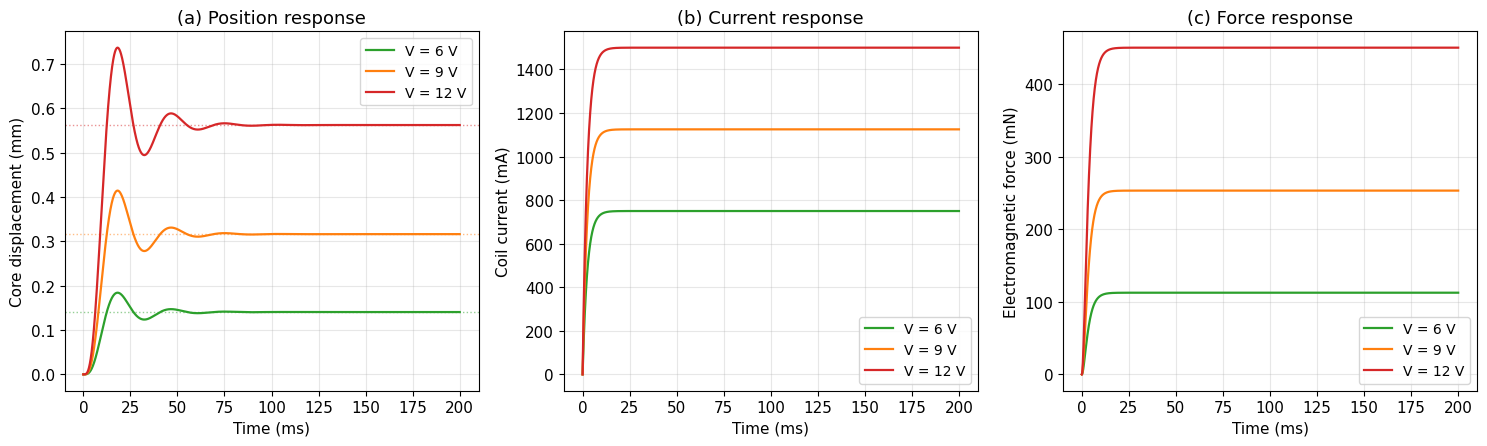

In [3]:
# ── Figure 12.1: Solenoid position, current, and force response ────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
colors = {6.0: 'tab:green', 9.0: 'tab:orange', 12.0: 'tab:red'}

ax = axes[0]
for V in voltages:
    t, sol = results[V]
    ax.plot(t*1000, sol[:, 0]*1000, color=colors[V], label=f'V = {V:.0f} V')
    ax.axhline(sol_act.x_ss_analytical(V)*1000, color=colors[V], ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Core displacement (mm)')
ax.set_title('(a) Position response'); ax.legend()

ax = axes[1]
for V in voltages:
    t, sol = results[V]
    ax.plot(t*1000, sol[:, 2]*1000, color=colors[V], label=f'V = {V:.0f} V')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Coil current (mA)')
ax.set_title('(b) Current response'); ax.legend()

ax = axes[2]
for V in voltages:
    t, sol = results[V]
    F_em = 0.5 * sol_act.Kf * sol[:, 2]**2
    ax.plot(t*1000, F_em*1000, color=colors[V], label=f'V = {V:.0f} V')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Electromagnetic force (mN)')
ax.set_title('(c) Force response'); ax.legend()

plt.tight_layout()
plt.show()


### Analysis

The electrical time constant ($\tau_e = L/R \approx 2.5$ ms) is about
**10.9 times** shorter than the mechanical period implied by the natural
frequency ($f_n \approx 36.8$ Hz, period $\approx 27.2$ ms). This
separation of timescales is why the current trace settles into a clean
first-order charging curve almost independently of the core's motion,
while the force trace (proportional to $i^2$) inherits that same fast
electrical rise.

The position response tells a different story: with a damping ratio of
0.289 (underdamped), the core overshoots the closed-form equilibrium
$x_{ss}=F_{em}(i_{ss})/k_{spring}$ by **31.0%**, settling to within 2% only
after **52.2 ms** — an order of magnitude longer than the current's
5.49 ms rise time.

Doubling the voltage from 6V to 12V exactly doubles the steady-state
current (Ohm's law), but **quadruples** the steady-state displacement
(0.1406 mm → 0.5625 mm): since $F_{em}\propto i^2$ and $i\propto V$ at
steady state, $F_{em}\propto V^2$, and because the spring is linear,
displacement inherits that same quadratic dependence.

**Takeaway:** this reduced-order model is reliable for transient *shape*
(overshoot, settling time, timescale separation, the $V^2$ displacement
scaling) but, because it omits the position-dependence of coil
inductance, it is not energy-conserving and must not be used to estimate
efficiency — that requires the fully coupled $L(x)$ model described
above.

---
## Exercise 12.2 — PWM-Driven DC Motor: Duty-Cycle Speed Control and Current Ripple

### Background

A microcontroller GPIO pin can only be fully on or fully off, so DC motors,
heaters, and LEDs are controlled with Pulse-Width Modulation (PWM) rather
than a variable analogue voltage. The GPIO pin never carries the motor
current directly — it drives the gate of a switching transistor, which
does the actual switching of the supply voltage. PWM controls the
*average applied terminal voltage*; for a resistive load this also
controls average power simply ($P=V^2/R$), but for a load with its own
back-EMF and inductance — a motor winding — average power is **not**
simply proportional to duty cycle.

**Driver topology matters.** This exercise assumes the common low-side-switch
topology: a transistor connects the motor to $V_{supply}$ during the ON
phase, and an **ideal freewheeling (flyback) diode** across the motor
terminals carries the current during the OFF phase, so $V(t)\approx 0$
(not $-V_{supply}$). Because a diode only conducts in one direction, if
back-EMF would otherwise drive the current negative, the diode blocks and
the winding current clamps to zero — **discontinuous conduction mode**
(DCM) — until the next ON pulse. A model without this clamp allows
unphysical negative current.

### Model

$$
L\,\frac{di}{dt} = V(t) - Ri - K_e\,\omega, \qquad
J\,\frac{d\omega}{dt} = K_t\,i - b\,\omega - T_{load}
$$

When the PWM period is much shorter than the motor's time constants
**and** the motor stays in continuous conduction (current never reaches
zero), it behaves as if driven by the average voltage $V_{avg}=D\cdot
V_{supply}$:
$$\omega_{ss} = \frac{K_t V_{avg} - R\,T_{load}}{K_t K_e + Rb}$$
In discontinuous conduction, this closed form can be **substantially
wrong in either direction** — this exercise measures, rather than
assumes, which way and by how much.

### Learning objectives

1. Derive and verify the duty-cycle/speed relationship, including the load-dependent offset (a *constant* shift across duty cycle, not a "fan out").
2. Simulate motor step responses using the averaged-voltage model.
3. Use a **fixed-step, diode-clamped** switched-model simulation (not `odeint`, which aliases against fast PWM) to measure how far the averaged model's prediction can be from the true mean speed once the motor falls into discontinuous conduction, and why.

In [4]:
class DCMotorActuator:
    """Brushed DC motor driven through a single low-side switch with an
    ideal freewheeling (flyback) diode across the motor terminals -- the
    standard low-side-switch PWM topology for driving a small brushed DC
    motor from a microcontroller GPIO pin via a MOSFET/driver IC. The
    GPIO pin drives the switch's gate; it is never connected to the motor
    winding directly.

    During the ON phase the switch connects the motor to V_supply. During
    the OFF phase the switch is open; as long as coil current is still
    flowing forward, the diode freewheels it (V_across_motor = 0 V, ideal
    diode, no forward drop). If the current would need to reverse, the
    ideal diode blocks conduction and current is clamped to zero --
    discontinuous conduction mode (DCM). This clamp is essential: without
    it, a naive V(t) in {0, Vsupply} model allows unphysical negative
    winding current.
    """
    def __init__(self, R=2.0, L=0.5e-3, Kt=0.02, Ke=0.02, J=3e-6, b=2e-6):
        self.R, self.L, self.Kt, self.Ke, self.J, self.b = R, L, Kt, Ke, J, b

    def steady_speed_avg_model(self, duty, Vsupply, T_load=0.0):
        """Steady-state speed from the averaged-terminal-voltage model.
        Valid in continuous conduction; in discontinuous conduction the
        motor alternates between full-voltage powered acceleration and
        open-circuit coasting, and this closed form can be substantially
        wrong in either direction depending on topology, load, and
        switching frequency (see simulate_switched below)."""
        Vavg = duty * Vsupply
        return (self.Kt*Vavg - self.R*T_load) / (self.Kt*self.Ke + self.R*self.b)

    def simulate_averaged(self, duty, Vsupply, t_span, n, T_load=0.0, state0=(0.0, 0.0)):
        """Continuous-time ODE (solved with odeint) driven by the averaged
        terminal voltage D*Vsupply applied directly -- what the averaged-
        voltage approximation assumes, with no switching to resolve.
        Used for panel (b), which specifically evaluates that
        approximation against itself."""
        Vavg = duty * Vsupply
        def rhs(state, t):
            i, omega = state
            di_dt = (Vavg - self.R*i - self.Ke*omega) / self.L
            domega_dt = (self.Kt*i - self.b*omega - T_load) / self.J
            return [di_dt, domega_dt]
        t = np.linspace(0, t_span, n)
        sol = odeint(rhs, state0, t)
        return t, sol

    def simulate_switched(self, duty, freq, Vsupply, t_span, T_load=0.0,
                           steps_per_period=100, state0=(0.0, 0.0)):
        """Fixed-step (explicit Euler) simulation of the actual switched
        PWM waveform, with >=100 steps per switching period so every PWM
        edge is resolved (odeint, used for the averaged model above, is
        not appropriate here: at high PWM frequency it aliases against
        the switching and gives incorrect results). Includes the
        ideal-diode current clamp described above.

        The ON/OFF phase is decided from the integer step index, not from
        a floating-point time modulo: comparing t[k-1] % period against a
        threshold is exposed to floating-point rounding right at period
        boundaries, which can misclassify a handful of steps per
        simulation (more at higher PWM frequency, where more boundaries
        are crossed) as ON when they should be OFF or vice versa. Using
        the step index directly is exact."""
        period = 1.0 / freq
        dt = period / steps_per_period
        n_steps = int(round(t_span / dt))
        n = n_steps + 1
        t = np.arange(n) * dt
        i = np.zeros(n); omega = np.zeros(n)
        i[0], omega[0] = state0
        on_steps = duty * steps_per_period
        for k in range(1, n):
            phase_step = (k - 1) % steps_per_period
            V = Vsupply if phase_step < on_steps else 0.0
            di_dt = (V - self.R*i[k-1] - self.Ke*omega[k-1]) / self.L
            domega_dt = (self.Kt*i[k-1] - self.b*omega[k-1] - T_load) / self.J
            i_new = i[k-1] + dt*di_dt
            omega_new = omega[k-1] + dt*domega_dt
            if V == 0.0 and i_new < 0.0:   # ideal diode blocks reverse conduction
                i_new = 0.0
            i[k], omega[k] = i_new, omega_new
        return t, i, omega


motor = DCMotorActuator()
Vsupply = 12.0
tau_e = motor.L / motor.R
tau_m = motor.R*motor.J / (motor.Kt*motor.Ke + motor.R*motor.b)
print(f"Electrical time constant tau_e = {tau_e*1e3:.4f} ms")
print(f"Electromechanical time constant tau_m (approx) = {tau_m*1e3:.3f} ms\n")

# ---- Panel (a): duty-cycle -> steady-state speed characteristic -------
duties = np.linspace(0.0, 1.0, 21)
loads = [0.0, 3e-3, 6e-3]  # N.m
speed_curves = {T: np.clip([motor.steady_speed_avg_model(d, Vsupply, T) for d in duties], 0, None)
                 for T in loads}
for T_load in loads:
    rpm = speed_curves[T_load]*60/(2*np.pi)
    print(f"T_load={T_load*1e3:.1f} mN.m: speed at duty=1.0 -> {rpm[-1]:.0f} RPM, "
          f"duty=0.5 -> {rpm[10]:.0f} RPM")
for T_load in loads[1:]:
    d_stall = motor.R*T_load / (motor.Kt*Vsupply)
    print(f"T_load={T_load*1e3:.1f} mN.m: theoretical stall duty cycle = {d_stall*100:.1f} %")

# ---- Panel (b): step response, AVERAGED-voltage model -----------------
t_span_step, n_step = 0.08, 4000
duty_list = [0.25, 0.5, 0.75, 1.0]
T_load_b = 3e-3
step_results = {}
print()
for d in duty_list:
    t, sol = motor.simulate_averaged(d, Vsupply, t_span_step, n_step, T_load=T_load_b)
    step_results[d] = (t, sol)
    omega_ss = sol[-1, 1]
    o10, o90 = 0.1*omega_ss, 0.9*omega_ss
    idx10 = np.where(sol[:,1] >= o10)[0]
    idx90 = np.where(sol[:,1] >= o90)[0]
    t_rise = (t[idx90[0]] - t[idx10[0]]) if len(idx10) and len(idx90) else np.nan
    print(f"duty={d:.2f}: omega_ss={omega_ss:.1f} rad/s ({omega_ss*60/(2*np.pi):.0f} RPM), "
          f"10-90% rise time={t_rise*1000:.2f} ms")

# ---- Panel (c)/(d): switched model vs. averaged model at duty=50% -----
# Resolution chosen after a convergence check (100/200/.../6400 steps per
# PWM period, with the ON/OFF phase decided from the integer step index
# rather than a floating-point time modulo -- see simulate_switched's
# docstring). With that exact phase logic, convergence is clean: mean
# speed is stable from 100 steps/period onward, and the 20 kHz
# current-ripple estimate is within ~0.1 percentage point of its
# converged value already at 100 steps/period (remaining Euler
# truncation error, not a phase-classification artefact). 2000
# steps/period is used below for extra margin; it is cheap to run and
# matches the fully converged (6400-step) values to 3 significant figures.
T_load_c = 6e-3
freqs = [200.0, 2000.0, 20000.0]
STEPS_PER_PERIOD = 2000
avg_speed_rpm = motor.steady_speed_avg_model(0.5, Vsupply, T_load_c) * 60/(2*np.pi)
ripple_results = {}
print(f"\nAveraged-model prediction at duty=50%, T_load=6 mN.m: {avg_speed_rpm:.0f} RPM")
for f in freqs:
    t, i, omega = motor.simulate_switched(0.5, f, Vsupply, 0.15, T_load=T_load_c,
                                           steps_per_period=STEPS_PER_PERIOD)
    tail_mask = t >= 0.14
    tail_i, tail_omega = i[tail_mask], omega[tail_mask]
    mode = "CCM" if tail_i.min() > 1e-6 else "DCM"
    mean_speed_rpm = tail_omega.mean()*60/(2*np.pi)
    ripple_results[f] = dict(t=t, i=i, omega=omega, mode=mode,
                              mean_i=tail_i.mean(), peak_i=tail_i.max(),
                              ripple=tail_i.max()-tail_i.min(),
                              mean_speed_rpm=mean_speed_rpm,
                              dev_pct=(mean_speed_rpm-avg_speed_rpm)/avg_speed_rpm*100)
    r = ripple_results[f]
    print(f"f={f:7.0f} Hz [{mode}]: mean speed={mean_speed_rpm:.0f} RPM "
          f"(averaged-model error: {r['dev_pct']:+.1f}%), mean current={r['mean_i']*1000:.1f} mA, "
          f"peak current={r['peak_i']*1000:.1f} mA, "
          f"ripple={r['ripple']*1000:.1f} mA ({r['ripple']/r['mean_i']*100:.0f}% of mean)")


Electrical time constant tau_e = 0.2500 ms
Electromechanical time constant tau_m (approx) = 14.851 ms

T_load=0.0 mN.m: speed at duty=1.0 -> 5673 RPM, duty=0.5 -> 2836 RPM
T_load=3.0 mN.m: speed at duty=1.0 -> 5531 RPM, duty=0.5 -> 2695 RPM
T_load=6.0 mN.m: speed at duty=1.0 -> 5389 RPM, duty=0.5 -> 2553 RPM
T_load=3.0 mN.m: theoretical stall duty cycle = 2.5 %
T_load=6.0 mN.m: theoretical stall duty cycle = 5.0 %

duty=0.25: omega_ss=133.1 rad/s (1271 RPM), 10-90% rise time=31.55 ms
duty=0.50: omega_ss=281.0 rad/s (2683 RPM), 10-90% rise time=31.53 ms
duty=0.75: omega_ss=428.9 rad/s (4095 RPM), 10-90% rise time=31.55 ms
duty=1.00: omega_ss=576.7 rad/s (5508 RPM), 10-90% rise time=31.55 ms

Averaged-model prediction at duty=50%, T_load=6 mN.m: 2553 RPM
f=    200 Hz [DCM]: mean speed=4946 RPM (averaged-model error: +93.8%), mean current=375.7 mA, peak current=832.4 mA, ripple=832.4 mA (222% of mean)


f=   2000 Hz [DCM]: mean speed=4006 RPM (averaged-model error: +56.9%), mean current=398.5 mA, peak current=1153.8 mA, ripple=1153.8 mA (290% of mean)


f=  20000 Hz [CCM]: mean speed=2553 RPM (averaged-model error: -0.0%), mean current=326.9 mA, peak current=476.8 mA, ripple=299.9 mA (92% of mean)


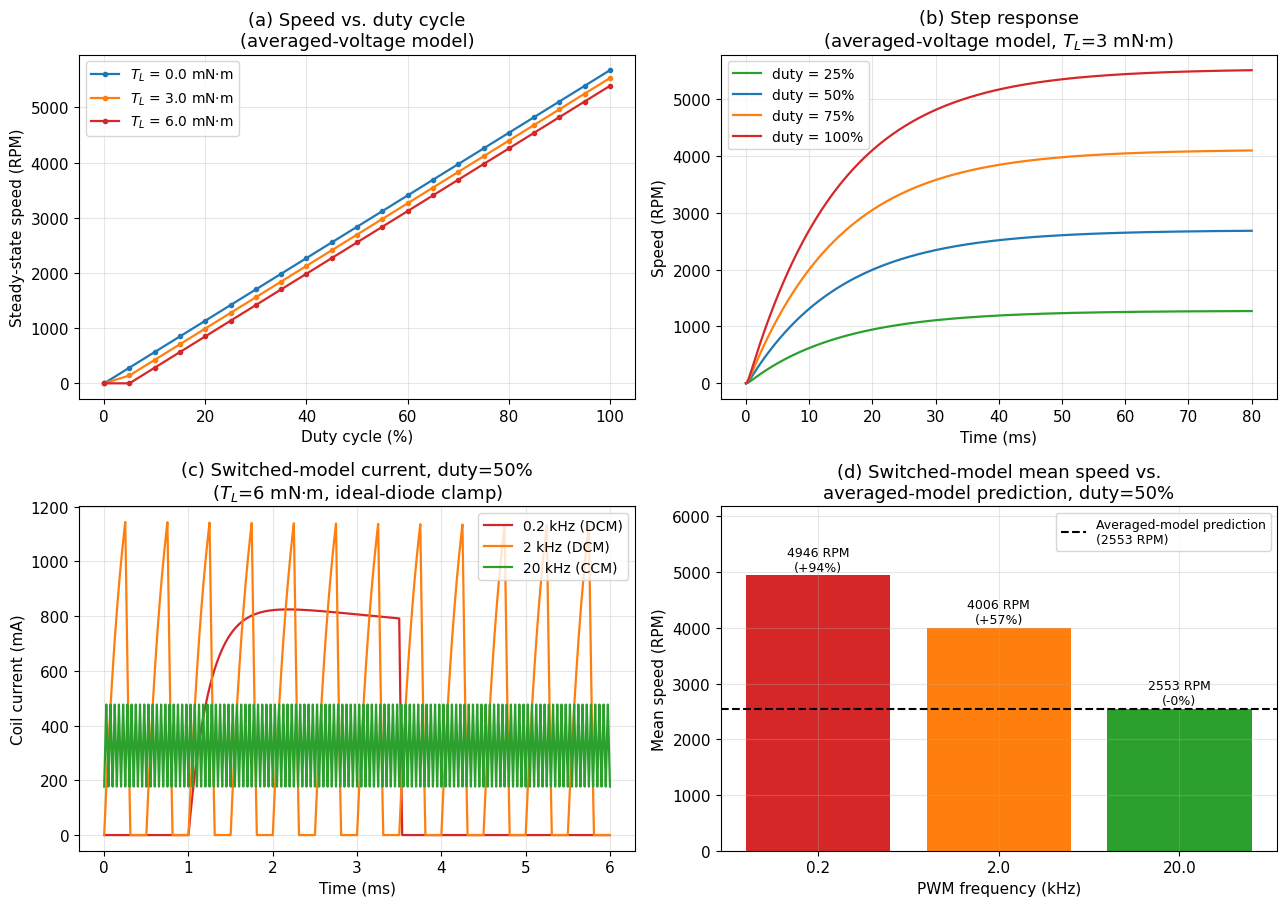

In [5]:
# ── Figure 12.2: PWM duty cycle, step response, current, and the ────────
# ── averaged-vs-switched speed discrepancy in discontinuous conduction ──
fig, axes = plt.subplots(2, 2, figsize=(13, 9.2))

ax = axes[0, 0]
colors_load = {0.0: 'tab:blue', 3e-3: 'tab:orange', 6e-3: 'tab:red'}
for T_load in loads:
    ax.plot(duties*100, speed_curves[T_load]*60/(2*np.pi), 'o-', ms=3, color=colors_load[T_load],
            label=f'$T_L$ = {T_load*1e3:.1f} mN·m')
ax.set_xlabel('Duty cycle (%)'); ax.set_ylabel('Steady-state speed (RPM)')
ax.set_title('(a) Speed vs. duty cycle\n(averaged-voltage model)'); ax.legend()

ax = axes[0, 1]
colors_duty = {0.25:'tab:green', 0.5:'tab:blue', 0.75:'tab:orange', 1.0:'tab:red'}
for d in duty_list:
    t, sol = step_results[d]
    ax.plot(t*1000, sol[:,1]*60/(2*np.pi), color=colors_duty[d], label=f'duty = {d*100:.0f}%')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Speed (RPM)')
ax.set_title('(b) Step response\n(averaged-voltage model, $T_L$=3 mN·m)'); ax.legend()

ax = axes[1, 0]
colors_f = {200.0:'tab:red', 2000.0:'tab:orange', 20000.0:'tab:green'}
labels_f = {200.0: '0.2 kHz (DCM)', 2000.0: '2 kHz (DCM)', 20000.0: '20 kHz (CCM)'}
for f in freqs:
    r = ripple_results[f]
    mask = (r['t'] >= 0.144) & (r['t'] <= 0.15)
    ax.plot((r['t'][mask]-0.144)*1000, r['i'][mask]*1000, color=colors_f[f], label=labels_f[f])
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Coil current (mA)')
ax.set_title('(c) Switched-model current, duty=50%\n($T_L$=6 mN·m, ideal-diode clamp)')
ax.legend()

ax = axes[1, 1]
freq_khz = [f/1000 for f in freqs]
mean_speeds = [ripple_results[f]['mean_speed_rpm'] for f in freqs]
bar_colors = [colors_f[f] for f in freqs]
bars = ax.bar([str(f) for f in freq_khz], mean_speeds, color=bar_colors)
ax.axhline(avg_speed_rpm, color='k', ls='--', lw=1.5, label=f'Averaged-model prediction\n({avg_speed_rpm:.0f} RPM)')
for bar, f in zip(bars, freqs):
    r = ripple_results[f]
    ax.text(bar.get_x()+bar.get_width()/2, r['mean_speed_rpm']+80,
            f"{r['mean_speed_rpm']:.0f} RPM\n({r['dev_pct']:+.0f}%)", ha='center', fontsize=9)
ax.set_xlabel('PWM frequency (kHz)'); ax.set_ylabel('Mean speed (RPM)')
ax.set_title('(d) Switched-model mean speed vs.\naveraged-model prediction, duty=50%')
ax.legend(fontsize=9)
ax.set_ylim(0, max(mean_speeds)*1.25)

plt.tight_layout()
plt.show()


### Analysis

Panel (a) confirms the linear duty-cycle/speed relationship. The three
load curves are, to within simulation precision, **parallel straight
lines**: the offset between $T_{load}=0$ and $T_{load}=6$ mN·m is 284 RPM
at *both* duty=0.5 and duty=1.0, exactly as the closed form predicts,
since the load term doesn't depend on duty cycle. (They converge toward
the origin only at very low duty, where the stall region clips them to
zero — a floor effect, not a fan-out.)

Panel (b) uses the averaged-voltage model directly, since that's what the
panel is evaluating in the first place.

Panels (c) and (d) tell the more interesting, and less textbook-tidy,
story once the switched waveform and ideal-diode clamp are simulated
directly — and the result runs against a hasty intuition. At both 200 Hz
and 2 kHz, this motor's low armature inductance (0.5 mH) can't sustain
current through the whole OFF interval, so it operates in **discontinuous
conduction at both frequencies** (panel c). Panel (d) shows what that
actually does to mean speed: at 200 Hz, the averaged model's prediction
(2553 RPM, dashed line) **understates** the true mean speed by **94%**
(4946 RPM actual); at 2 kHz, by 57% (4006 RPM). The mechanism is a
"pulse-and-coast" pattern: during the long ON pulse the motor accelerates
under the *full* 12V supply (not the 6V average), and once current has
decayed to zero during OFF the motor coasts with no electrical torque at
all. Because the powered phase drives the motor toward a much higher
instantaneous speed than 6V would produce, and coasting doesn't fully
undo that gain before the next pulse, the net effect is a substantially
*higher* mean speed than the averaged model predicts — the opposite of
what "DCM means weaker effective drive" would suggest. Only at 20 kHz
does the motor cross into continuous conduction, where the switched
model's mean speed matches the averaged model almost exactly.

The current values in the printed output are easy to misread if you
compare mean current alone: it's essentially flat between 200 Hz
(376 mA) and 2 kHz (399 mA), while *peak* current rises substantially
(832 mA → 1154 mA). This is a back-EMF effect — the motor runs *faster*
on average at 200 Hz, so its back-EMF is higher, which limits how much
current the same 12V pulse can drive before it ends; at 2 kHz, lower
mean speed means less back-EMF opposition and a higher peak current for
a shorter pulse. Once continuous conduction is reached at 20 kHz,
mechanical speed ripple becomes negligible (~0.01% of mean — the
rotor's inertia low-pass-filters torque ripple) even though *current*
ripple remains substantial at 92% of mean — continuous conduction
suppresses speed ripple far more effectively than current ripple, and
the two shouldn't be conflated. Raising switching frequency to reach
CCM does reduce current/torque ripple, but it's not free: higher
frequency also increases switching losses in the driver, so real driver
selection balances both effects rather than simply maximising frequency.

*(Numerical note: the ON/OFF phase is decided from the integer PWM step
index, not a floating-point time modulo, which avoids misclassifying
steps right at period boundaries. With that exact phase logic, panels
(c)/(d) — run at 2000 steps per PWM period, chosen after a convergence
check from 100 up to 6400 steps per period — are stable to within
~0.1 percentage point of their fully converged values already at 100
steps/period; the remaining difference is ordinary Euler truncation
error, not a phase-classification artefact.)*

**Takeaway:** the averaged-voltage model is only as good as the
continuous-conduction assumption behind it. In discontinuous conduction,
a motor doesn't behave like a smaller version of its CCM self — it
alternates between full-voltage acceleration and open-circuit coasting,
and the resulting error in the averaged model (94% and 57% here) can go
in *either* direction depending on topology, load, and back-EMF, which is
exactly why it needs to be checked with a switched-model simulation
rather than assumed.

---
## Exercise 12.3 — Open-Loop vs. Closed-Loop PID Position Control

### Background

This exercise compares three actuators with different gains and time
constants — representative of nominally identical valves or motor stages
that drifted apart through manufacturing tolerance — commanded two ways:
an **uncalibrated nominal feedforward** signal $u=\mathrm{setpoint}$
(open loop, assuming unity gain), versus the same PID controller applied
unchanged to all three (closed loop). A step load disturbance is injected
partway through. (A model-based open-loop controller that *knew* each
actuator's true gain could remove the steady-state gain error by
commanding $u=\mathrm{setpoint}/K$ — it still couldn't reject the
disturbance, which is the more fundamental point here.)

### Model

$$\tau\,\dot{x} = -x + Ku + d(t), \qquad
u_k = K_p e_k + K_i\sum_{j\le k}e_j\Delta t + K_d\frac{e_k-e_{k-1}}{\Delta t}$$

**On honest metrics:** a naive settling-time calculation can silently
report the *edge of the analysis window* as if it were a real settling
time, when the system never actually entered the tolerance band. The
code below reports `None` (printed as "N/A (not settled)") in that case,
rather than a misleading number — and the simulation window is 3.0 s
(not 2.0 s), long enough for the post-disturbance recovery to actually
finish before being measured.

### Learning objectives

1. Observe that open-loop steady-state error is always $K\times$ setpoint — a permanent offset, not a transient.
2. Verify that a *single*, untuned-per-actuator PID design compensates for heterogeneous gain and time constant.
3. See that a disturbance shifts every actuator's raw *output* by the same amount, but its effect on tracking *error* depends on the sign of any pre-existing gain error (it can even improve the error).
4. Use settling time, recovery time, peak/final error, and integral absolute error (IAE) together, rather than a single potentially misleading number.

In [6]:
class FirstOrderActuator:
    """Generic first-order actuator plant: tau*dx/dt = -x + K*u + d(t)."""
    def __init__(self, K, tau):
        self.K, self.tau = K, tau

    def simulate_open_loop(self, setpoint, t_span, dt, disturbance_fn=None):
        """Open loop here means an *uncalibrated nominal feedforward*
        command u = setpoint -- i.e. the command assumes unity gain. A
        model-based open-loop controller that knew K in advance could set
        u = setpoint / K and remove the steady-state gain error (but would
        still be unable to reject the unmeasured disturbance introduced
        below)."""
        n = int(t_span/dt) + 1
        t = np.linspace(0, t_span, n)
        x = np.zeros(n)
        for k in range(1, n):
            d = disturbance_fn(t[k-1]) if disturbance_fn else 0.0
            u = setpoint
            dxdt = (-x[k-1] + self.K*u + d) / self.tau
            x[k] = x[k-1] + dt*dxdt
        return t, x

    def simulate_pid(self, setpoint, t_span, dt, Kp, Ki, Kd, disturbance_fn=None):
        n = int(t_span/dt) + 1
        t = np.linspace(0, t_span, n)
        x = np.zeros(n)
        integral = 0.0
        prev_error = setpoint - x[0]
        for k in range(1, n):
            d = disturbance_fn(t[k-1]) if disturbance_fn else 0.0
            error = setpoint - x[k-1]
            integral += error*dt
            derivative = (error - prev_error)/dt
            u = Kp*error + Ki*integral + Kd*derivative
            dxdt = (-x[k-1] + self.K*u + d) / self.tau
            x[k] = x[k-1] + dt*dxdt
            prev_error = error
        return t, x


actuators = [
    {'name': 'Actuator 1', 'K': 1.0, 'tau': 0.10, 'setpoint': 1.0, 'color': 'tab:blue'},
    {'name': 'Actuator 2', 'K': 1.2, 'tau': 0.15, 'setpoint': 0.8, 'color': 'tab:orange'},
    {'name': 'Actuator 3', 'K': 0.8, 'tau': 0.08, 'setpoint': 1.2, 'color': 'tab:green'},
]
Kp, Ki, Kd = 2.0, 8.0, 0.02
DIST_T0 = 1.0          # disturbance onset
t_span, dt = 3.0, 0.001  # extended so post-disturbance recovery is fully visible

def disturbance(t):
    return -0.3 if t >= DIST_T0 else 0.0

results_ol, results_cl = {}, {}
for a in actuators:
    plant = FirstOrderActuator(a['K'], a['tau'])
    results_ol[a['name']] = plant.simulate_open_loop(a['setpoint'], t_span, dt, disturbance)
    results_cl[a['name']] = plant.simulate_pid(a['setpoint'], t_span, dt, Kp, Ki, Kd, disturbance)


def analyse(t, x, setpoint, dt):
    """Honest metrics: settling times report 'not settled' (None) rather
    than silently returning the edge of the analysis window; steady-state
    error is read off the *end* of a window long enough to have actually
    converged; IAE is reported over both phases."""
    band = 0.02 * abs(setpoint)

    # pre-disturbance settling time (window [0, DIST_T0))
    mask_pre = t < DIST_T0
    t_pre, x_pre = t[mask_pre], x[mask_pre]
    outside_pre = np.where(np.abs(x_pre - setpoint) > band)[0]
    if len(outside_pre) == 0:
        t_settle_pre = 0.0
    elif outside_pre[-1] + 1 < len(t_pre):
        t_settle_pre = t_pre[outside_pre[-1] + 1]
    else:
        t_settle_pre = None  # never entered the band before the disturbance

    final_error_pre = abs(setpoint - x_pre[-1])

    # post-disturbance recovery time (time from DIST_T0 to re-entering band and staying)
    mask_post = t >= DIST_T0
    t_post, x_post = t[mask_post], x[mask_post]
    outside_post = np.where(np.abs(x_post - setpoint) > band)[0]
    if len(outside_post) == 0:
        t_recover = 0.0
    elif outside_post[-1] + 1 < len(t_post):
        t_recover = t_post[outside_post[-1] + 1] - DIST_T0
    else:
        t_recover = None  # never re-settled within the simulated window

    peak_error_post = np.abs(setpoint - x_post).max()
    final_error_post = abs(setpoint - x_post[-1])  # end of a 2 s post-disturbance window
    iae = np.sum(np.abs(setpoint - x)) * dt

    return dict(t_settle_pre=t_settle_pre, final_error_pre=final_error_pre,
                t_recover=t_recover, peak_error_post=peak_error_post,
                final_error_post=final_error_post, iae=iae)


def fmt(v, unit=""):
    return "N/A (not settled)" if v is None else f"{v:.3f}{unit}"

print(f"{'Actuator':<12}{'Mode':<10}{'t_settle_pre':>16}{'err_pre(final)':>16}"
      f"{'t_recover':>14}{'peak_err_post':>16}{'err_post(final)':>18}{'IAE':>10}")
for a in actuators:
    for label, res in [('Open-loop', results_ol[a['name']]), ('PID', results_cl[a['name']])]:
        t_, x_ = res
        m = analyse(t_, x_, a['setpoint'], dt)
        print(f"{a['name']:<12}{label:<10}{fmt(m['t_settle_pre']):>16}{m['final_error_pre']:>16.4f}"
              f"{fmt(m['t_recover']):>14}{m['peak_error_post']:>16.4f}{m['final_error_post']:>18.4f}"
              f"{m['iae']:>10.3f}")

# check: does every PID response actually stay within 2% by the end of the run?
print("\nFinal (t=3.0s) PID tracking check:")
for a in actuators:
    t_, x_ = results_cl[a['name']]
    err = abs(a['setpoint'] - x_[-1])
    within2 = err <= 0.02*abs(a['setpoint'])
    print(f"{a['name']}: final error = {err:.4f} ({err/a['setpoint']*100:.2f}% of setpoint), "
          f"within 2% band: {within2}")


Actuator    Mode          t_settle_pre  err_pre(final)     t_recover   peak_err_post   err_post(final)       IAE
Actuator 1  Open-loop            0.390          0.0000N/A (not settled)          0.3000            0.3000     0.670
Actuator 1  PID                  0.871          0.0135         0.654          0.0929            0.0003     0.162
Actuator 2  Open-loop N/A (not settled)          0.1588N/A (not settled)          0.1588            0.1400     0.422
Actuator 2  PID                  0.649          0.0048         0.635          0.0737            0.0002     0.115
Actuator 3  Open-loop N/A (not settled)          0.2400N/A (not settled)          0.5400            0.5400     1.373
Actuator 3  PID       N/A (not settled)          0.0277         0.720          0.1186            0.0007     0.234

Final (t=3.0s) PID tracking check:
Actuator 1: final error = 0.0003 (0.03% of setpoint), within 2% band: True
Actuator 2: final error = 0.0002 (0.02% of setpoint), within 2% band: True
Actuator 3:

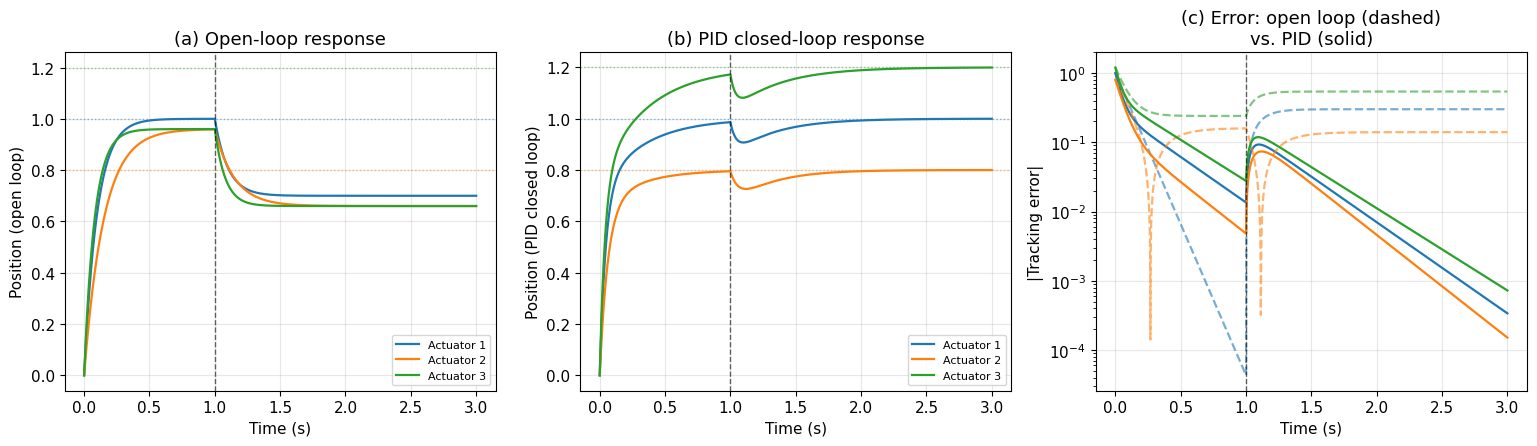

In [7]:
# ── Figure 12.3: Open-loop vs. PID closed-loop tracking ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

ax = axes[0]
for a in actuators:
    t_ol, x_ol = results_ol[a['name']]
    ax.plot(t_ol, x_ol, color=a['color'], label=a['name'])
    ax.axhline(a['setpoint'], color=a['color'], ls=':', alpha=0.5, lw=1)
ax.axvline(DIST_T0, color='k', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position (open loop)')
ax.set_title('(a) Open-loop response'); ax.legend(fontsize=8)

ax = axes[1]
for a in actuators:
    t_cl, x_cl = results_cl[a['name']]
    ax.plot(t_cl, x_cl, color=a['color'], label=a['name'])
    ax.axhline(a['setpoint'], color=a['color'], ls=':', alpha=0.5, lw=1)
ax.axvline(DIST_T0, color='k', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Position (PID closed loop)')
ax.set_title('(b) PID closed-loop response'); ax.legend(fontsize=8)

ax = axes[2]
for a in actuators:
    t_ol, x_ol = results_ol[a['name']]
    t_cl, x_cl = results_cl[a['name']]
    ax.plot(t_ol, np.abs(a['setpoint'] - x_ol), color=a['color'], ls='--', alpha=0.6)
    ax.plot(t_cl, np.abs(a['setpoint'] - x_cl), color=a['color'], ls='-')
ax.axvline(DIST_T0, color='k', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Time (s)'); ax.set_ylabel('|Tracking error|')
ax.set_title('(c) Error: open loop (dashed)\nvs. PID (solid)')
ax.set_yscale('log')

plt.tight_layout()
plt.show()


### Analysis

Actuator 1 ($K=1.0$) settles to its setpoint in 0.390 s — purely by
coincidence, since $u=\mathrm{setpoint}$ only works when $K=1$. Actuators
2 and 3 never enter the 2% band pre-disturbance at all (their gain
mismatch alone exceeds 2%), correctly reported as `None`/N/A rather than
a fabricated number.

The disturbance at $t=1.0$s shifts every actuator's raw output by exactly
$-0.3$ (linearity of the plant), but its effect on **tracking error**
depends on the sign of the pre-existing error: for Actuator 3 (already
20% *below* setpoint), the error nearly triples (0.240 → 0.540); for
Actuator 2 (already 20% *above* setpoint), the disturbance happens to
pull it back toward the setpoint, and the error actually **improves**
slightly (0.159 → 0.140). None of the open-loop actuators ever recover
afterward.

Under PID, all three actuators recover to the 2% band within 0.65–0.72 s
of the disturbance and reach sub-0.1% final error by $t=3.0$s. The
integral-absolute-error (IAE) column summarises both the transient and
disturbance-rejection behaviour in one number: PID cuts IAE by a factor
of 4–6 relative to open loop for every actuator.

**Takeaway:** a disturbance's effect on tracking error is not simply
"add the disturbance magnitude" — it depends on which direction any
existing error already points, even though the plant's raw *output*
does shift by exactly the disturbance amount in every case. PID's
integral term is what turns that shift into a recoverable transient
instead of a permanent one.

---
## Exercise 12.4 — Piezoelectric vs. Shape-Memory-Alloy Actuators: Response-Time and Hysteresis Trade-offs

### Background

Section 12.2 introduces piezoelectric and shape-memory-alloy (SMA)
actuators as two very different ways of turning an electrical signal into
motion. Both are nonlinear and both exhibit hysteresis, but for entirely
different physical reasons, and response time differs by roughly three
orders of magnitude. *(Scope note: the hysteresis measured below is
open-loop accuracy/nonlinearity, not metrological precision in the
stricter repeatability sense — this exercise does not attempt to
quantify precision that way.)*

### Model

Piezo: $x = d_{eff}\,y(V)$, where $y(V)$ is a play (backlash) hysteresis
operator, $y_k=\max(V_k-r,\min(V_k+r,y_{k-1}))$. **Note:** this model
has no stack capacitance $C$, so it cannot estimate actuation energy
($E=\tfrac12 CV^2$ would require adding $C$ — see the challenge tasks in
the printed chapter).

SMA: $C_{th}\dot T = P - hA(T-T_{amb})$, with strain mapped from
temperature via two different logistic curves for heating (referenced to
$A_s,A_f$) and cooling (referenced to $M_s,M_f$), producing the thermal
hysteresis loop.

### Learning objectives

1. Reproduce a realistic piezoelectric hysteresis loop and quantify its width.
2. Simulate a full SMA heating/cooling cycle and observe the resulting thermal hysteresis loop.
3. Compare response times quantitatively and connect the gap to the underlying transduction physics (electric field vs. heat diffusion) — while recognising that driver voltage, preload, geometry, and cooling can still shift response time *within* a technology class.

In [8]:
# ── Exercise 12.4: Piezoelectric vs. SMA actuators ──────────────────────
class PiezoStackActuator:
    """Piezoelectric stack actuator with a play-operator (backlash-type)
    hysteresis model, driven quasi-statically by an applied voltage."""
    def __init__(self, d_eff=0.6e-6, play_radius=8.0, tau_dyn=50e-6):
        self.d_eff = d_eff       # effective displacement coeff. [m/V] (stack)
        self.r = play_radius     # hysteresis play radius [V]
        self.tau_dyn = tau_dyn   # electromechanical bandwidth time const. [s]

    def hysteresis_output(self, V):
        y = np.zeros_like(V)
        y_prev = 0.0
        for k in range(len(V)):
            y_prev = max(V[k] - self.r, min(V[k] + self.r, y_prev))
            y[k] = y_prev
        return y

    def step_response(self, t_span=0.001, n=2000, V_step=100.0):
        t = np.linspace(0, t_span, n)
        def rhs(x, t):
            return (self.d_eff*V_step - x) / self.tau_dyn
        x = odeint(rhs, 0.0, t).flatten()
        return t, x


piezo = PiezoStackActuator()
Vmax, n_half = 150.0, 3000
V_up = np.linspace(0, Vmax, n_half)
V_down = np.linspace(Vmax, 0, n_half)
V_cycle = np.concatenate([V_up, V_down[1:]])
x_cycle = piezo.d_eff * piezo.hysteresis_output(V_cycle)
x_up, x_down = x_cycle[:n_half], x_cycle[n_half-1:]

mid_up = np.argmin(np.abs(V_up - Vmax/2))
mid_down = np.argmin(np.abs(V_down - Vmax/2))
full_scale = x_cycle.max()
hysteresis_pct = (x_down[mid_down] - x_up[mid_up]) / full_scale * 100

print(f"Full-scale displacement @ {Vmax:.0f} V: {full_scale*1e6:.2f} um")
print(f"Hysteresis width @ mid-scale (V={Vmax/2:.0f} V): {hysteresis_pct:.2f} % of full scale")

t_step, x_step = piezo.step_response()
x_ss_p = x_step[-1]
t10 = t_step[np.where(x_step >= 0.1*x_ss_p)[0][0]]
t90 = t_step[np.where(x_step >= 0.9*x_ss_p)[0][0]]
piezo_rise_time = t90 - t10
print(f"Piezo 10-90% rise time: {piezo_rise_time*1e6:.1f} us  "
      f"(approx. bandwidth ~ {0.35/piezo_rise_time/1e3:.2f} kHz)\n")


class SMAWireActuator:
    """Lumped-thermal-mass NiTi wire actuator with a heating/cooling
    transformation hysteresis loop (simplified logistic phase-fraction
    model; stress-dependence of the transformation temperatures is
    neglected)."""
    def __init__(self, R=6.0, C_th=0.01908, hA=6.6e-3, T_amb=25.0,
                 As=68.0, Af=78.0, Ms=52.0, Mf=42.0, max_strain=0.04):
        self.R, self.C_th, self.hA, self.T_amb = R, C_th, hA, T_amb
        self.As, self.Af, self.Ms, self.Mf = As, Af, Ms, Mf
        self.max_strain = max_strain  # 4% recoverable strain, typical NiTi

    def temperature(self, I_of_t, t_span, n):
        t = np.linspace(0, t_span, n)
        T = np.zeros(n); T[0] = self.T_amb
        dt = t[1] - t[0]
        for k in range(1, n):
            P = I_of_t(t[k-1])**2 * self.R
            dTdt = (P - self.hA*(T[k-1] - self.T_amb)) / self.C_th
            T[k] = T[k-1] + dt*dTdt
        return t, T

    def strain_heating(self, T):
        mid, width = (self.As + self.Af)/2, (self.Af - self.As)/4
        return self.max_strain / (1 + np.exp(-(T - mid)/width))

    def strain_cooling(self, T):
        mid, width = (self.Ms + self.Mf)/2, (self.Ms - self.Mf)/4
        return self.max_strain / (1 + np.exp(-(T - mid)/width))


sma = SMAWireActuator()
I_heat, t_on, t_off = 0.40, 3.0, 9.0
t_span_sma, n_sma = t_on + t_off, 12000

def I_of_t(t):
    return I_heat if t < t_on else 0.0

t_sma, T_sma = sma.temperature(I_of_t, t_span_sma, n_sma)
peak_idx = np.argmax(T_sma)
strain_sma = np.zeros_like(T_sma)
strain_sma[:peak_idx+1] = sma.strain_heating(T_sma[:peak_idx+1])
strain_sma[peak_idx+1:] = sma.strain_cooling(T_sma[peak_idx+1:])
for k in range(peak_idx+1, len(strain_sma)):
    strain_sma[k] = min(strain_sma[k], strain_sma[k-1])  # strain cannot re-increase while cooling

T_peak, strain_peak = T_sma[peak_idx], strain_sma[peak_idx]
idx10 = np.where(strain_sma[:peak_idx+1] >= 0.1*strain_peak)[0]
idx90 = np.where(strain_sma[:peak_idx+1] >= 0.9*strain_peak)[0]
sma_rise_time = t_sma[idx90[0]] - t_sma[idx10[0]]

post_peak_t, post_peak_strain = t_sma[peak_idx:], strain_sma[peak_idx:]
below10 = np.where(post_peak_strain <= 0.1*strain_peak)[0]
sma_recovery_time = post_peak_t[below10[0]] - post_peak_t[0]

print(f"Peak wire temperature: {T_peak:.1f} C  (Af = {sma.Af:.0f} C)")
print(f"Peak strain: {strain_peak*100:.2f} %  (max_strain = {sma.max_strain*100:.1f} %)")
print(f"Heating 10-90% strain rise time: {sma_rise_time:.3f} s")
print(f"Cooling recovery time (strain to <10%): {sma_recovery_time:.3f} s")
print(f"Electrical power during heating: {I_heat**2*sma.R:.3f} W")
print(f"Electrical energy input over {t_on:.0f} s heating pulse: {I_heat**2*sma.R*t_on:.3f} J")
print(f"\nSpeed comparison: piezo rise time = {piezo_rise_time*1e6:.1f} us vs. "
      f"SMA rise time = {sma_rise_time:.3f} s -> SMA is ~{sma_rise_time/piezo_rise_time:.0f}x slower")


Full-scale displacement @ 150 V: 85.20 um
Hysteresis width @ mid-scale (V=75 V): 11.30 % of full scale
Piezo 10-90% rise time: 110.1 us  (approx. bandwidth ~ 3.18 kHz)

Peak wire temperature: 118.9 C  (Af = 78 C)
Peak strain: 4.00 %  (max_strain = 4.0 %)
Heating 10-90% strain rise time: 0.327 s
Cooling recovery time (strain to <10%): 5.026 s
Electrical power during heating: 0.960 W
Electrical energy input over 3 s heating pulse: 2.880 J

Speed comparison: piezo rise time = 110.1 us vs. SMA rise time = 0.327 s -> SMA is ~2971x slower


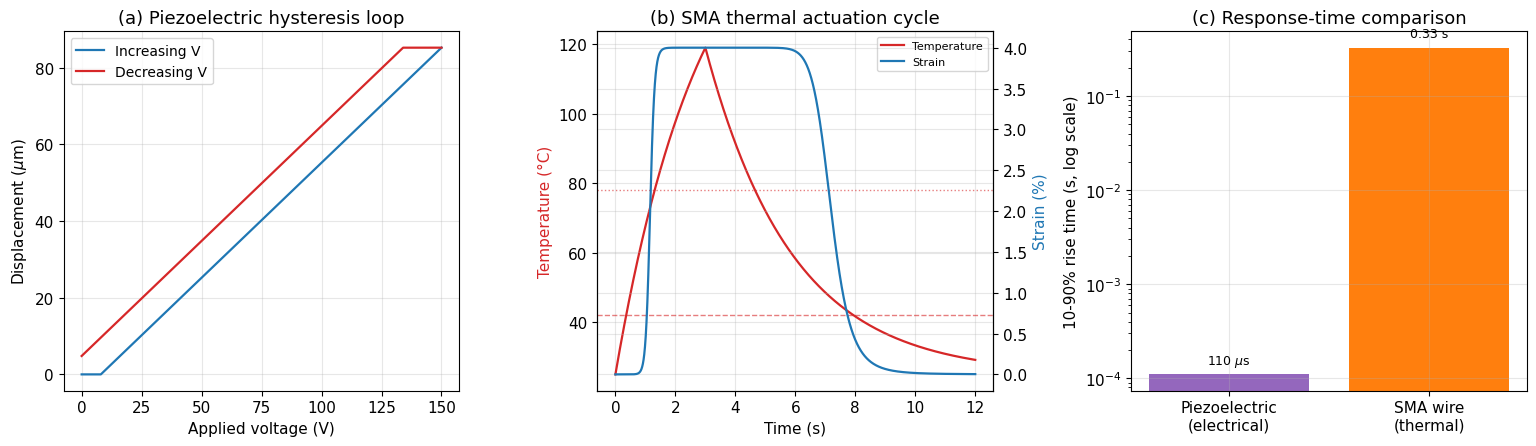

In [9]:
# ── Figure 12.4: Piezo hysteresis loop, SMA thermal cycle, response time ─
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

ax = axes[0]
ax.plot(V_up, x_up*1e6, color='tab:blue', label='Increasing V')
ax.plot(V_down, x_down*1e6, color='tab:red', label='Decreasing V')
ax.set_xlabel('Applied voltage (V)'); ax.set_ylabel('Displacement ($\\mu$m)')
ax.set_title('(a) Piezoelectric hysteresis loop'); ax.legend()

ax = axes[1]
ax2 = ax.twinx()
l1, = ax.plot(t_sma, T_sma, color='tab:red', label='Temperature')
ax.axhline(sma.Af, color='tab:red', ls=':', lw=1, alpha=0.6)
ax.axhline(sma.Mf, color='tab:red', ls='--', lw=1, alpha=0.6)
l2, = ax2.plot(t_sma, strain_sma*100, color='tab:blue', label='Strain')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Temperature (\u00b0C)', color='tab:red')
ax2.set_ylabel('Strain (%)', color='tab:blue')
ax.set_title('(b) SMA thermal actuation cycle')
ax.legend(handles=[l1, l2], fontsize=8, loc='upper right')

ax = axes[2]
techs = ['Piezoelectric\n(electrical)', 'SMA wire\n(thermal)']
times = [piezo_rise_time, sma_rise_time]
bars = ax.bar(techs, times, color=['tab:purple', 'tab:orange'])
ax.set_yscale('log')
ax.set_ylabel('10-90% rise time (s, log scale)')
ax.set_title('(c) Response-time comparison')
for bar, val in zip(bars, times):
    label = f'{val*1e6:.0f} $\\mu$s' if val < 1e-3 else f'{val:.2f} s'
    ax.text(bar.get_x()+bar.get_width()/2, val*1.3, label, ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### Analysis

The piezo stack's voltage-displacement loop is about 11.3% wide at
mid-scale, in the 10-15% range typically quoted for multilayer PZT
stacks. Full-scale travel of ~85 μm at 150V is representative of a
centimetre-scale stack.

The SMA wire's full heating/cooling cycle shows the thermal hysteresis
signature clearly: strain doesn't start rising until temperature nears
$A_s$, and doesn't start falling again during cooling until temperature
drops well below $A_f$, past $M_s$ — a ~26°C loop. The 2.88 J electrical
input over the 3s heating pulse is dominated by resistive heating and
convective loss, not useful mechanical work; no efficiency figure is
claimed, for the same reason none was claimed for the solenoid in
Exercise 12.1.

The response-time contrast is stark, using the same 10-90% rise-time
definition for both technologies so the comparison is apples-to-apples:
the piezo stack's 10-90% rise time is ~110 μs; the SMA wire's 10-90%
strain rise time while heating is ~0.327s — nearly **3000× slower for
the representative actuator dimensions and parameters used in this
exercise** (this ratio is not a universal constant; it shifts with wire
diameter, drive current, and piezo stack geometry) — plus a further ~5s
to recover during passive cooling. This gap traces to what each
technology fundamentally relies on: the electrical excitation in a
piezo stack is established rapidly, and the resulting mechanical strain
then propagates through the material as an acoustic wave at a velocity
set by the material's stiffness and density (still microsecond-scale
for a stack a few centimetres long) — it is the strain wave, not the
electric field itself, that travels at an acoustic-wave velocity. An
SMA actuator, by contrast, must wait for heat to diffuse through the
wire and then leave via convection.

**Takeaway:** the dominant timescale is set by transduction physics —
electric-field-driven (piezo) vs. heat-driven (SMA) — not by the driver
electronics. Driver voltage/current, preload, geometry, and active
cooling can meaningfully shift response time *within* a technology class,
but they cannot close a three-order-of-magnitude gap set by the
underlying physics.

---
## Summary

| Exercise | Technique | Practical benefit |
|----------|-----------|-------------------|
| 12.1 | Coupled electrical-mechanical ODE | Predicts solenoid overshoot and settling time — and shows why the model must *not* be reused to estimate efficiency |
| 12.2 | Averaged-voltage model + fixed-step switched model with diode clamp | Shows when a motor actually reaches continuous conduction, and that ripple doesn't always shrink monotonically with frequency in DCM |
| 12.3 | Discrete-time PID with honest settling/recovery metrics | Demonstrates quantitatively why closed-loop control is needed under gain uncertainty or disturbances, without hiding "not settled" cases |
| 12.4 | Hysteresis operator + lumped thermal model | Explains the microsecond-vs-second response gap between electrical and thermal actuation |

All four exercises share a modelling habit worth internalising: state the
governing equations and parameters explicitly, reproduce results with a
fixed random seed, and — just as importantly — know which questions a
given reduced-order model can and cannot answer honestly (Exercise 12.1's
energy-conservation caveat and Exercise 12.3's settling-time handling are
both examples of the same discipline). The discrete-time PID update law in
Exercise 12.3 also forms the computational core of an embedded PID
implementation, but practical deployment on a microcontroller requires
more than this update law alone: output saturation handling,
anti-windup, derivative-term filtering, a fixed-rate scheduling loop,
sensor/actuator signal scaling, and hardware-level fail-safe limits.
Readers
moving on to Chapter 13 (Data Acquisition Fundamentals) will use the same
ODE-based simulation habit applied to the sensing side of the
sense-decide-act loop that actuators close.